# Imports
* First, turn on the fan, clean the robot (Live tumor only). Clean the shaking ring and the plastic insert it sits in especially carefully.


In [1]:
import sys
import os

# Add the upstream directory to sys.path
upstream_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if upstream_dir not in sys.path:
    sys.path.insert(0, upstream_dir)

from opentrons_api import ot2_api
from microtissue_manipulator import core, utils, camera
import numpy as np 
import cv2
import time
import json
import keyboard
import paths
import matplotlib.pyplot as plt
import requests
import datetime
import threading
import queue
import string
import pandas as pd
import multiprocessing as mp
from dataclasses import dataclass, fields, asdict, MISSING
from typing import get_type_hints, get_origin, get_args, Tuple, List, Dict, Any, Union
from ultralytics import YOLO
from enum import Enum
import matplotlib.pyplot as plt


# Start the camera
* make sure the camera is plugged into the computer before runing the following cell
* if camera doesn't work, unplug and replug the camera or restart the notebook

In [ ]:
cam_manager = camera.CameraManagerWindows()
print("Connected cameras:")
print(cam_manager.list_devices())

under_cam = camera.open_capture('underview_cam', cam_manager=cam_manager, resolution = (4000,3000), focus = 900)
over_cam = camera.open_capture('overview_cam_2', cam_manager=cam_manager)
frame_ops = camera.frameOperations(*over_cam.shape[0:-1])

calibration_profile = 'checkerboard'
frame_ops.load_camera_intrinsics(config_profile=calibration_profile, use_new_cam_mtx=True)

time.sleep(3)
ret, _ = under_cam.read()
if ret:
    print("Under camera is working correctly.")
else:
    print("Under camera is not working.")

ret, _ = over_cam.read()
if ret:
    print("Over camera is working correctly.")
else:
    print("Over camera is not working.")

# Initialization
* connects the robot to the computer, robot setup

In [2]:
# Connect the robot to the computer and this notebook
openapi = ot2_api.OpentronsAPI()

In [3]:
# Set the offset if the platform is used
openapi.add_slot_offsets([5,8,9], (0,0,64.2))

In [5]:
# Use the light control to see if the robot is connected as a sanity check
openapi.toggle_lights()

<Response [200]>

In [6]:
# Always do once after robot was just turned on 
openapi.home_robot()

Request status:
<Response [200]>
{
  "message": "Homing robot."
}


<Response [200]>

In [7]:
# Run this cell after the first run
openapi.create_run()

Request status:
<Response [201]>
{
  "data": {
    "id": "6d56abe5-abf3-44d3-8975-1b8bbefbb0e2",
    "ok": true,
    "createdAt": "2025-06-27T18:03:17.233065Z",
    "status": "idle",
    "current": true,
    "actions": [],
    "errors": [],
    "hasEverEnteredErrorRecovery": false,
    "pipettes": [],
    "modules": [],
    "labware": [],
    "liquids": [],
    "liquidClasses": [],
    "labwareOffsets": [],
    "runTimeParameters": [],
    "outputFileIds": []
  }
}


<Response [201]>

In [8]:
# Let the robot know it has pipettor p300
openapi.load_pipette()

Request status:
<Response [201]>
{
  "data": {
    "id": "d1d84ebe-5b25-47d0-bee2-10b25b0ac15a",
    "createdAt": "2025-06-27T18:03:23.398428Z",
    "commandType": "loadPipette",
    "key": "d1d84ebe-5b25-47d0-bee2-10b25b0ac15a",
    "status": "succeeded",
    "params": {
      "pipetteName": "p300_single_gen2",
      "mount": "left"
    },
    "result": {
      "pipetteId": "9713263b-b770-48d5-831d-54e464c4e088"
    },
    "startedAt": "2025-06-27T18:03:23.401736Z",
    "completedAt": "2025-06-27T18:03:25.311223Z",
    "intent": "setup",
    "notes": []
  }
}


<Response [201]>

## Caution!
* If crash happens/notebook restarts, the code will obtain the labware information from the robot and transfer them back to notebook
* If a previous run already exits, you can "remember" the previous labware set up without needing to start a new run. 

In [ ]:
# Use to restore labware and general run information after the notebook crashes
openapi.get_run_info()

# Declare labware
* Tell the robot that a well plate and pipette tip is coming

### opentrons 300 uL (Sterile, for live tumor only)

* be aware of where the tip rack is

In [9]:
#Define a tip rack. This is the default tip rack for the robot.
TIP_RACK = "opentrons_96_tiprack_300ul"
#Load the tip rack. Slot = 1 by default.
# Change the slot number if the Black Pipette tiprack is in different spot
r = openapi.load_labware(TIP_RACK, 11)

Labware ID:
4b9b08d8-aeb4-40b4-ae72-9c04c7b52c73



* Be aware the location of pipette tip before running the cell below

In [10]:
 # Pick up the pipette tip at a specific location, change the location number if needed
r = openapi.pick_up_tip(openapi.labware_dct['11'], "A1")

### VWR 200 uL XL

In [ ]:
custom_labware_path = os.path.join(paths.BASE_DIR,'protocols','vwr_96_tiprack_200ul_xl.json')
with open(custom_labware_path, 'r') as json_file:
    custom_labware = json.load(json_file)

command_dict = {
            "data": custom_labware
        }

command_payload = json.dumps(command_dict)

url = openapi.get_url('runs')+ f'/{openapi.run_id}/'+ 'labware_definitions'
r = requests.post(url = url, headers = openapi.HEADERS, params = {"waitUntilComplete": True}, data = command_payload)
#Define a tip rack. This is the default tip rack for the robot.
TIP_RACK = "vwr_96_tiprack_200ul_xl"
#Load the tip rack. Slot = 1 by default.
openapi.load_labware(TIP_RACK, 10, namespace='custom_beta',verbose=True)

* Check if the pipette tiprack is in slot 10, if not, put it in!
* Check the location of the tip, make sure there's a tip in the tiprack

In [ ]:
 # Pick up the pipette tip at a specific location, change the location number if needed
r = openapi.pick_up_tip(openapi.labware_dct['10'], "A5")

In [ ]:
openapi.drop_tip_in_place()

### Declare well plate

In [11]:
# Putting in a 6 well plate to slot 4
RESERVOIR = "corning_6_wellplate_16.8ml_flat"
r = openapi.load_labware(RESERVOIR, 4, namespace='opentrons',verbose=True)

Labware ID:
9f525c6e-208a-4454-8ceb-c6244615f4ce



In [12]:
# Comment/uncomment to change well plate type
# WELL_PLATE = "corning_96_wellplate_360ul_flat"
WELL_PLATE = "corning_6_wellplate_16.8ml_flat"
# WELL_PLATE = "corning_24_wellplate_3.4ml_flat"
# WELL_PLATE = "corning_384_wellplate_112ul_flat"
r = openapi.load_labware(WELL_PLATE, 5, namespace='opentrons',verbose=True)

Offset (0, 0, 64.2) added to run for corning_6_wellplate_16.8ml_flat in slot 5.
Labware URI:
opentrons/corning_6_wellplate_16.8ml_flat/1

Check offset before using ...
Labware ID:
90126b0d-a1b5-4d6b-ad31-4846af40734f



* If you want to change different well plate, tell the robot to forget previous well plate using this code first

In [ ]:
openapi.move_labware(openapi.labware_dct['5'], new_location='offDeck')

# Layouts of holes on the agarose gel block
* To have a preview of the location of each hole will be before punching

Total holes: 169


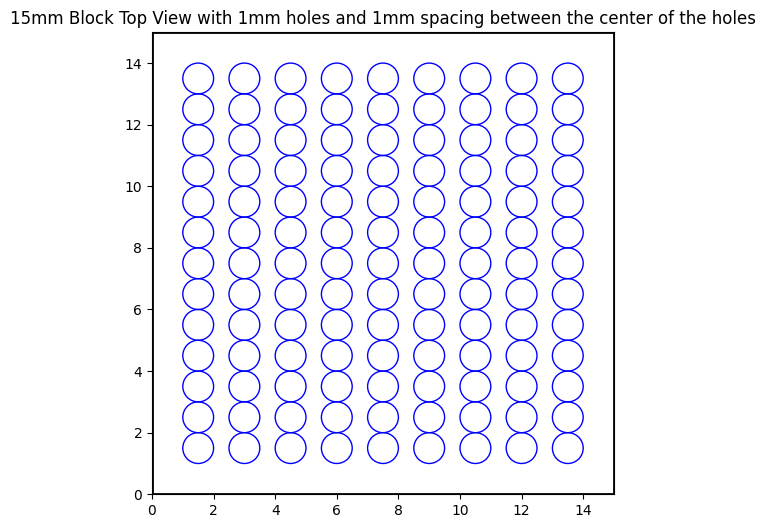

In [33]:
# Define parameters
cube_size = 15 #size of the agarose gel blcok in mm
half_cube_size = cube_size / 2
hole_diameter = 1
hole_radius = hole_diameter / 2
spacing = 1 # spacing between hole centers (touching but not overlapping)
edge_offset = 1

# Generate hole centers
start = edge_offset + hole_radius
end = cube_size - (edge_offset + hole_radius)

centers = np.arange(start, end + 1e-6, spacing)
hole_centers = []
for x in centers:
    for y in centers:
        hole_centers.append((x, y))

hole_count = len(hole_centers)
print("Total holes:", hole_count)

#shift columns
column_gap = 0.5  # extra space between columns
adjusted_holes = []

for x, y in hole_centers:
    col_index = int(round((x - start) / spacing))

    # shift column
    new_x = x + col_index * column_gap

    adjusted_holes.append((new_x, y))

# Plot
fig, ax = plt.subplots(figsize=(6,6))

# draw square block
square = plt.Rectangle((0,0), cube_size, cube_size,
                       fill=False, linewidth=2)
ax.add_patch(square)

# draw holes
valid_holes = []

for x, y in adjusted_holes:
    if (x - hole_radius >= 0 and 
        x + hole_radius <= cube_size and
        y - hole_radius >= 0 and
        y + hole_radius <= cube_size):
        valid_holes.append((x, y))

for (x,y) in valid_holes:
    circle = plt.Circle((x,y), hole_radius, edgecolor='blue', facecolor='none')
    ax.add_patch(circle)

ax.set_aspect('equal')
ax.set_xlim(0, cube_size)
ax.set_ylim(0, cube_size)

# Update title to reflect the spacing
ax.set_title(f"15mm Block Top View with 1mm holes and 1mm spacing between the center of the holes")

plt.show()

# Punch holes

* Generate holes coordinates

Total holes: 100


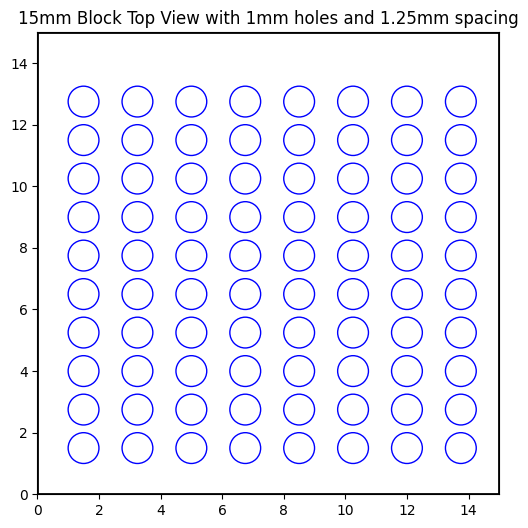

In [21]:
# Define parameters
cube_size = 15 #size of the agarose gel blcok in mm
half_cube_size = cube_size / 2
hole_diameter = 1
hole_radius = hole_diameter / 2
spacing = 1.25 # spacing between hole centers (touching but not overlapping)
edge_offset = 1

# Generate hole centers
start = edge_offset + hole_radius
end = cube_size - (edge_offset + hole_radius)

centers = np.arange(start, end + 1e-6, spacing)
hole_centers = []
for x in centers:
    for y in centers:
        hole_centers.append((x, y))

hole_count = len(hole_centers)
print("Total holes:", hole_count)

# Plot
fig, ax = plt.subplots(figsize=(6,6))

# draw square block
square = plt.Rectangle((0,0), cube_size, cube_size,
                       fill=False, linewidth=2)
ax.add_patch(square)

# draw holes coordinates
for (x,y) in valid_holes:
    circle = plt.Circle((x,y), hole_radius, edgecolor='blue', facecolor='none')
    ax.add_patch(circle)

ax.set_aspect('equal')
ax.set_xlim(0, cube_size)
ax.set_ylim(0, cube_size)

# Update title to reflect the spacing
ax.set_title(f"15mm Block Top View with 1mm holes and 1.25mm spacing")

plt.show()
# print("Hole coordinates:", coords)

In [35]:
valid_holes

[(1.5, 1.5),
 (1.5, 2.5),
 (1.5, 3.5),
 (1.5, 4.5),
 (1.5, 5.5),
 (1.5, 6.5),
 (1.5, 7.5),
 (1.5, 8.5),
 (1.5, 9.5),
 (1.5, 10.5),
 (1.5, 11.5),
 (1.5, 12.5),
 (1.5, 13.5),
 (3.0, 1.5),
 (3.0, 2.5),
 (3.0, 3.5),
 (3.0, 4.5),
 (3.0, 5.5),
 (3.0, 6.5),
 (3.0, 7.5),
 (3.0, 8.5),
 (3.0, 9.5),
 (3.0, 10.5),
 (3.0, 11.5),
 (3.0, 12.5),
 (3.0, 13.5),
 (4.5, 1.5),
 (4.5, 2.5),
 (4.5, 3.5),
 (4.5, 4.5),
 (4.5, 5.5),
 (4.5, 6.5),
 (4.5, 7.5),
 (4.5, 8.5),
 (4.5, 9.5),
 (4.5, 10.5),
 (4.5, 11.5),
 (4.5, 12.5),
 (4.5, 13.5),
 (6.0, 1.5),
 (6.0, 2.5),
 (6.0, 3.5),
 (6.0, 4.5),
 (6.0, 5.5),
 (6.0, 6.5),
 (6.0, 7.5),
 (6.0, 8.5),
 (6.0, 9.5),
 (6.0, 10.5),
 (6.0, 11.5),
 (6.0, 12.5),
 (6.0, 13.5),
 (7.5, 1.5),
 (7.5, 2.5),
 (7.5, 3.5),
 (7.5, 4.5),
 (7.5, 5.5),
 (7.5, 6.5),
 (7.5, 7.5),
 (7.5, 8.5),
 (7.5, 9.5),
 (7.5, 10.5),
 (7.5, 11.5),
 (7.5, 12.5),
 (7.5, 13.5),
 (9.0, 1.5),
 (9.0, 2.5),
 (9.0, 3.5),
 (9.0, 4.5),
 (9.0, 5.5),
 (9.0, 6.5),
 (9.0, 7.5),
 (9.0, 8.5),
 (9.0, 9.5),
 (9.0, 10.5),
 (9.

* Using the function to find the coordinates of the offset
* shortcuts: up/down/left/right to move in x and y plane, control+up/down to move in z direction
* step size: 0.01, 0.1, 0.5,  1, 3, 5, 10, 30, 50 (mm), by default, step size always starts in 1 mm, and press +/- key can increase or decrease the stepsize

In [21]:
manual_movement = utils.ManualRobotMovement(openapi)

In [26]:
openapi.toggle_lights()

<Response [200]>

In [22]:
openapi.move_relative('z', -10)

<Response [201]>

In [25]:
openapi.retract_axis('leftZ')

<Response [201]>

* turn off the manual control of robot

In [27]:
keyboard.unhook_all()

* tells you the cordinates of the tip

In [24]:
openapi.get_position()

{'x': 195.8843109410696, 'y': 115.74480470671767, 'z': 67.6}


({'x': 195.8843109410696, 'y': 115.74480470671767, 'z': 67.6},
 <Response [201]>)

In [36]:
x_punch_offset = 189.88540953188786
y_punch_offset = 106.74570437714044
well_bottom_z = 67.6
safe_z = well_bottom_z + 5
max_volume=200
punch_volume=50
waste_slot_number = '4'
waste_well_number = 'B1'

In [37]:
coordinates = np.array(valid_holes+ np.array([x_punch_offset, y_punch_offset]))
print(coordinates)

[[     191.39      108.25]
 [     191.39      109.25]
 [     191.39      110.25]
 [     191.39      111.25]
 [     191.39      112.25]
 [     191.39      113.25]
 [     191.39      114.25]
 [     191.39      115.25]
 [     191.39      116.25]
 [     191.39      117.25]
 [     191.39      118.25]
 [     191.39      119.25]
 [     191.39      120.25]
 [     192.89      108.25]
 [     192.89      109.25]
 [     192.89      110.25]
 [     192.89      111.25]
 [     192.89      112.25]
 [     192.89      113.25]
 [     192.89      114.25]
 [     192.89      115.25]
 [     192.89      116.25]
 [     192.89      117.25]
 [     192.89      118.25]
 [     192.89      119.25]
 [     192.89      120.25]
 [     194.39      108.25]
 [     194.39      109.25]
 [     194.39      110.25]
 [     194.39      111.25]
 [     194.39      112.25]
 [     194.39      113.25]
 [     194.39      114.25]
 [     194.39      115.25]
 [     194.39      116.25]
 [     194.39      117.25]
 [     194.39      118.25]
 

In [43]:
coordinates1 = coordinates[5:35]
print(coordinates1)

[[     191.39      113.25]
 [     191.39      114.25]
 [     191.39      115.25]
 [     191.39      116.25]
 [     191.39      117.25]
 [     191.39      118.25]
 [     191.39      119.25]
 [     191.39      120.25]
 [     192.89      108.25]
 [     192.89      109.25]
 [     192.89      110.25]
 [     192.89      111.25]
 [     192.89      112.25]
 [     192.89      113.25]
 [     192.89      114.25]
 [     192.89      115.25]
 [     192.89      116.25]
 [     192.89      117.25]
 [     192.89      118.25]
 [     192.89      119.25]
 [     192.89      120.25]
 [     194.39      108.25]
 [     194.39      109.25]
 [     194.39      110.25]
 [     194.39      111.25]
 [     194.39      112.25]
 [     194.39      113.25]
 [     194.39      114.25]
 [     194.39      115.25]
 [     194.39      116.25]]


In [44]:
def punch_hole(openapi, coordinates, volume_counter):
    
    x, y = coordinates
    
    # Move to right above the hole position
    openapi.move_to_coordinates((x, y, safe_z))
    
    # Move down into gel
    openapi.move_to_coordinates((x, y, well_bottom_z))
    for _ in range(3):
        openapi.move_relative('z', -0.2)
        time.sleep(0.1)
        openapi.move_relative('z', 0.2)
    
    # Aspirate agarose
    openapi.aspirate_in_place(volume = punch_volume, flow_rate=200)
    for _ in range (10):
        openapi.move_relative('z', 0.2)
        time.sleep(0.1)
    volume_counter += punch_volume
    
    # Move back up
    openapi.move_to_coordinates((x, y, safe_z))
    
    # If tip is full, dump
    if volume_counter >= max_volume:
        openapi.move_to_well(labware_id=openapi.labware_dct[waste_slot_number], well_name=waste_well_number, well_location="center")
        openapi.dispense(labware_id=openapi.labware_dct[waste_slot_number], well_name=waste_well_number, well_location='center', volume=200) 
        volume_counter = 0

    
    return volume_counter

* loop through holes in one well

In [45]:
def punch_holes_in_well(openapi, coords):
    openapi.blow_out(labware_id=openapi.labware_dct[waste_slot_number], well_name=waste_well_number, well_location="center")
    openapi.aspirate(labware_id=openapi.labware_dct[waste_slot_number], well_name=waste_well_number, well_location="center")
    openapi.dispense(labware_id=openapi.labware_dct[waste_slot_number], well_name=waste_well_number, well_location="center")
    volume_counter = 0
    
    for coord in coords:
        volume_counter = punch_hole(openapi, coord, volume_counter)
    
    # dump the rediduals in the pipette tip after finishing all holes in the well
    if volume_counter > 0:
        openapi.move_to_well(labware_id=openapi.labware_dct[waste_slot_number], well_name=waste_well_number, well_location="center")
        openapi.dispense(labware_id=openapi.labware_dct[waste_slot_number], well_name=waste_well_number, well_location="center", volume=200)
    openapi.retract_axis('leftZ')

In [46]:
punch_holes_in_well(openapi, coordinates1)

Request status:
<Response [201]>
{
  "data": {
    "id": "9c0e1717-7f43-49ad-b6a2-1f2826d3ac0a",
    "createdAt": "2025-06-27T18:29:41.456926Z",
    "commandType": "moveToCoordinates",
    "key": "9c0e1717-7f43-49ad-b6a2-1f2826d3ac0a",
    "status": "succeeded",
    "params": {
      "minimumZHeight": 20.0,
      "forceDirect": false,
      "pipetteId": "9713263b-b770-48d5-831d-54e464c4e088",
      "coordinates": {
        "x": 191.38540953188786,
        "y": 113.24570437714044,
        "z": 72.6
      }
    },
    "result": {
      "position": {
        "x": 191.38540953188786,
        "y": 113.24570437714044,
        "z": 72.6
      }
    },
    "startedAt": "2025-06-27T18:29:41.459627Z",
    "completedAt": "2025-06-27T18:29:43.219850Z",
    "intent": "setup",
    "notes": []
  }
}
Request status:
<Response [201]>
{
  "data": {
    "id": "f0af1903-678a-4c66-8c03-0ea0c0261dc2",
    "createdAt": "2025-06-27T18:29:43.258209Z",
    "commandType": "moveToCoordinates",
    "key": "f0af190

# Robot to Camera calibration
* mapping the two coordinate systems: creating a relation between the pixels of the camera and the real-world coordinates of the robot.
* MAKE SURE the white pad light at the bottom is on!!

In [ ]:
# If the lights were on, turn them off using this code
openapi.toggle_lights()

* "Aim" the robot: adjust camera focus and robot position in relation to the calibration target
* +/- sign on the keyboard increases the stepsize, up/down/left/right keys can shift the robot's position

In [ ]:
squaresX=7
squaresY=5 
squareLength=0.022
markerLength=0.011
aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_6X6_250)
params = cv2.aruco.DetectorParameters()
detector = cv2.aruco.ArucoDetector(aruco_dict, params)
board = cv2.aruco.CharucoBoard((squaresX, squaresY), squareLength, markerLength, aruco_dict)
calibration_data = utils.load_calibration_config(calibration_profile)
manual_movement = utils.ManualRobotMovement(openapi)

calib_origin = calibration_data['calib_origin']
openapi.move_to_coordinates(calib_origin, min_z_height=1, verbose=False)

cv2.namedWindow("video", cv2.WINDOW_NORMAL)
cv2.resizeWindow("video", 1348, 1011)

robot_coords = []
new_calib_origin = None

while True:
 # Capture frame-by-frame
    ret, frame = over_cam.read()
    # frame = frame_ops.undistort_frame(frame)

    x, y, z = openapi.get_position(verbose=False)[0].values()
    (text_width, text_height), _ = cv2.getTextSize(f"Robot coords: ({x:.2f}, {y:.2f}, {z:.2f})", cv2.FONT_HERSHEY_SIMPLEX, 1, 2)
    cv2.rectangle(frame, (10, 0), (10 + text_width, text_height + 100), (0, 0, 0), -1)
    cv2.putText(frame, f"Robot coords: ({x:.2f}, {y:.2f}, {z:.2f})", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(frame, f"Step size: {manual_movement.step} mm", (10, 70), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    center_screen_x = frame.shape[1] // 2
    center_screen_y = frame.shape[0] // 2
    cv2.circle(frame, (center_screen_x, center_screen_y), 5, (0, 0, 255), -1)
    cv2.putText(frame, f"Center: ({center_screen_x}, {center_screen_y})", (center_screen_x + 10, center_screen_y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

    # Calculate the center of each quarter of the screen
    quarter_centers = [
        (center_screen_x // 2, center_screen_y // 2),
        (3 * center_screen_x // 2, center_screen_y // 2),
        (center_screen_x // 2, 3 * center_screen_y // 2),
        (3 * center_screen_x // 2, 3 * center_screen_y // 2)
    ]

    # Draw circles at the center of each quarter
    for qx, qy in quarter_centers:
        cv2.circle(frame, (qx, qy), 5, (0, 255, 255), -1)
        cv2.putText(frame, f"({qx}, {qy})", (qx + 10, qy - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)
    marker_corners, marker_ids, _ = detector.detectMarkers(frame)
    if marker_corners:
        for corner in marker_corners:
            corner = corner.reshape((4, 2))
            for point in corner:
                cv2.circle(frame, tuple(point.astype(int)), 5, (0, 255, 0), -1)

            center_x = int(np.mean(corner[:, 0]))
            center_y = int(np.mean(corner[:, 1]))
            cv2.circle(frame, (center_x, center_y), 5, (255, 0, 0), -1)
            cv2.putText(frame, f"({center_x}, {center_y})", (center_x + 10, center_y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    # Calculate side lengths
    side_lengths = []
    if marker_corners:
        for corner in marker_corners[0]:
            for i in range(4):
                side_length = np.linalg.norm(corner[i] - corner[(i + 1) % 4])
                side_lengths.append(side_length)

    # Calculate the average side length
        average_side_length = np.mean(side_lengths)
        area = cv2.contourArea(marker_corners[0])
        one_d_ratio = 13.83 / average_side_length
        size_conversion_ratio = 13.83 ** 2 / area
        cv2.putText(frame, f"Area of marker: {area:.2f}", (10, 110), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.imshow("video", frame)

    key_pressed = cv2.waitKey(1)

    if key_pressed == ord('q'):
        keyboard.unhook_all()
        x, y, z = openapi.get_position(verbose=False)[0].values()
        new_calib_origin = (x, y, z)
        break

# When everything done, release the capture
# cap.release_camera()
cv2.destroyAllWindows()

calibration_data = utils.load_calibration_config(calibration_profile)
calibration_data['size_conversion_ratio'] = size_conversion_ratio
calibration_data['one_d_ratio'] = one_d_ratio
if new_calib_origin:
    calibration_data['calib_origin'] = new_calib_origin
    print(f"New calibration origin set to: {new_calib_origin}")

utils.save_calibration_config(calibration_profile, calibration_data)

* execute the calibration

In [ ]:
calibration_data = utils.load_calibration_config(calibration_profile)
calib_origin = calibration_data['calib_origin']

spacing = 5  # Distance from the calib_point in mm

# Calculate the four coordinates
calibration_points = [
    (calib_origin[0] + spacing, calib_origin[1] + spacing),  # Right
    (calib_origin[0] + spacing, calib_origin[1] - spacing),  # Left
    (calib_origin[0] - spacing, calib_origin[1] - spacing),  # Up
    (calib_origin[0] - spacing, calib_origin[1] + spacing)   # Down
]

robot_coords = []
camera_coords = []


# window = cap.get_window()
cv2.namedWindow("video", cv2.WINDOW_NORMAL)
cv2.resizeWindow("video", 1348, 1011)

for calib_pt in calibration_points:
    openapi.move_to_coordinates((*calib_pt, 100), min_z_height=1, verbose=False)
    cv2.waitKey(1000)
    # frame = cap.get_frame(undist=True)
    ret, frame = over_cam.read()
    frame = frame_ops.undistort_frame(frame)
    
    x, y, z = openapi.get_position(verbose=False)[0].values()
    (text_width, text_height), _ = cv2.getTextSize(f"Robot coords: ({x:.2f}, {y:.2f}, {z:.2f})", cv2.FONT_HERSHEY_SIMPLEX, 1, 2)
    cv2.rectangle(frame, (10, 0), (10 + text_width, text_height + 70), (0, 0, 0), -1)
    cv2.putText(frame, f"Robot coords: ({x:.2f}, {y:.2f}, {z:.2f})", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(frame, f"Step size: {manual_movement.step} mm", (10, 70), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    center_screen_x = frame.shape[1] // 2
    center_screen_y = frame.shape[0] // 2
    cv2.circle(frame, (center_screen_x, center_screen_y), 5, (0, 0, 255), -1)
    cv2.putText(frame, f"Center: ({center_screen_x}, {center_screen_y})", (center_screen_x + 10, center_screen_y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

    # Calculate the center of each quarter of the screen
    quarter_centers = [
        (center_screen_x // 2, center_screen_y // 2),
        (3 * center_screen_x // 2, center_screen_y // 2),
        (center_screen_x // 2, 3 * center_screen_y // 2),
        (3 * center_screen_x // 2, 3 * center_screen_y // 2)
    ]

    # Draw circles at the center of each quarter
    for qx, qy in quarter_centers:
        cv2.circle(frame, (qx, qy), 5, (0, 255, 255), -1)
        cv2.putText(frame, f"({qx}, {qy})", (qx + 10, qy - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)

    marker_corners, marker_ids, _ = detector.detectMarkers(frame)
    if marker_corners:
        for corner in marker_corners:
            corner = corner.reshape((4, 2))
            for point in corner:
                cv2.circle(frame, tuple(point.astype(int)), 5, (0, 255, 0), -1)

            center_x = int(np.mean(corner[:, 0]))
            center_y = int(np.mean(corner[:, 1]))
            cv2.circle(frame, (center_x, center_y), 5, (255, 0, 0), -1)
            cv2.putText(frame, f"({center_x}, {center_y})", (center_x + 10, center_y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    cv2.waitKey(1)
    cv2.imshow("video", frame)
    x, y, z = openapi.get_position(verbose=False)[0].values()
    robot_coords.append((x, y))
    camera_coords.append((center_x, center_y))

cv2.destroyAllWindows()

calibration_data = utils.load_calibration_config(calibration_profile)

camera_coords = utils.sort_coordinates(camera_coords)
robot_coords = utils.sort_coordinates(robot_coords, reverse_y=True)

robot_to_camera_coords = {tuple(robot_coord): tuple(camera_coord) for robot_coord, camera_coord in zip(robot_coords, camera_coords)}
tf_mtx = utils.compute_tf_mtx(robot_to_camera_coords)

calibration_data['tf_mtx'] = tf_mtx.tolist()

utils.save_calibration_config(calibration_profile, calibration_data)

# Pipette offset calibration

In [ ]:
# Need the lights on for this process
openapi.toggle_lights()

* excute automatic pipette calibration
* align crosshair to center of the image and press q for quit
* manually change the location of the crosshair disk to ensure it's center aligns with the camera

In [ ]:
path = os.path.join(paths.BASE_DIR, 'outputs', 'images', 'target_template_2.png')
template = cv2.imread(path, 0)  # Replace 'template.png' with your template image path
template_height, template_width = template.shape[:2]
calibration_data = utils.load_calibration_config(calibration_profile)
tf_mtx = np.array(calibration_data['tf_mtx'])
calib_origin = np.array(calibration_data['calib_origin'])[:2]
tip_calib_origin = np.array(calibration_data['tip_calib_origin'])
offset = np.array(calibration_data['offset'])
model_path = os.path.join(paths.ML_MODELS_DIR,'tip_detector_v1.pt')
model = YOLO(model_path)


#Settings
calib_module_height = 69  # Height for the pipette offset calibration module
detection_offset_x = -4
detection_offset_y = 0  # Offset to apply to the detected coordinates
#Move to pipette offset calibration module:
openapi.move_to_coordinates(tip_calib_origin, min_z_height=calib_module_height-0.1, verbose=False)

cv2.namedWindow("video", cv2.WINDOW_NORMAL)
cv2.resizeWindow("video", 1348, 1011)

manual_movement = utils.ManualRobotMovement(openapi)
new_tip_calib_origin = None
while True:
 # Capture frame-by-frame
    ret, frame = over_cam.read()
    frame = frame_ops.undistort_frame(frame)

    x, y, z = openapi.get_position(verbose=False)[0].values()
    (text_width, text_height), _ = cv2.getTextSize(f"Robot coords: ({x:.2f}, {y:.2f}, {z:.2f})", cv2.FONT_HERSHEY_SIMPLEX, 1, 2)
    cv2.rectangle(frame, (10, 0), (10 + text_width, text_height + 100), (0, 0, 0), -1)
    cv2.putText(frame, f"Robot coords: ({x:.2f}, {y:.2f}, {z:.2f})", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(frame, f"Step size: {manual_movement.step} mm", (10, 70), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    center_screen_x = frame.shape[1] // 2
    center_screen_y = frame.shape[0] // 2
    cv2.circle(frame, (center_screen_x, center_screen_y), 5, (0, 0, 255), -1)
    cv2.putText(frame, f"Center: ({center_screen_x}, {center_screen_y})", (center_screen_x + 10, center_screen_y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

    cv2.imshow("video", frame)
    key_pressed = cv2.waitKey(1)

    if key_pressed == ord('q'):
        keyboard.unhook_all()
        x, y, z = openapi.get_position(verbose=False)[0].values()
        new_tip_calib_origin = (x, y, z)
        break

cv2.destroyAllWindows()


ret, frame = over_cam.read()
assert ret, "Failed to capture frame from over_cam."
frame = frame_ops.undistort_frame(frame)
image = frame.copy()
plot_img_over = frame.copy()
image = image[..., ::-1]  # Convert BGR to RGB as YOLO expects RGB input
results = model.predict(
        source=image,  # Now pointing to a directory instead of a single file
        conf=0.25,         # Confidence threshold
        save=False,         # Save the annotated images
        save_txt=False,    # Save YOLO-format prediction labels (optional)
        show=False,         # Show images in pop-up windows (if GUI available)
        imgsz=2016,
        verbose = False               # Ensure inference matches your training resolution
    )

image_center = (image.shape[1] // 2, image.shape[0] // 2)
data = []
for r in results:
    for box in r.boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        center_x = (x1 + x2) // 2
        center_y = (y1 + y2) // 2
        data.append({'class': model.names[cls], 'confidence': conf, 'center_x': center_x, 'center_y': center_y})

        if model.names[cls] == 'point':
            color = (0, 255, 0)  # Green for points
        else:
            color = (0, 0, 255)  # Red for tips
            
        # Draw rectangle around the detected object
        cv2.rectangle(plot_img_over, (x1, y1), (x2, y2), color, 2)

        # Add label with class name and confidence score
        label = f"{model.names[cls]} {conf:.2f}"
        cv2.putText(plot_img_over, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        # Draw center point of detection
        cv2.circle(plot_img_over, (center_x, center_y), 4, color, -1)


# Select the point closest to the center of the image
if data:
    closest_obj = min(
        (obj for obj in data if obj['class'] == 'point'),
        key=lambda obj: (obj['center_x'] - image_center[0]) ** 2 + (obj['center_y'] - image_center[1]) ** 2,
        default=None
    )
    if closest_obj is not None:
        cv2.circle(frame, (closest_obj['center_x'], closest_obj['center_y']), 8, (0, 255, 255), 2)
        cv2.putText(frame, "Closest", (closest_obj['center_x'] + 10, closest_obj['center_y'] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
assert closest_obj is not None, "No 'point' class detected in the image."
crosshair_x, crosshair_y = closest_obj['center_x'], closest_obj['center_y']

#Move to the center of the detected template
X_init, Y_init, _ = tf_mtx @ (crosshair_x, crosshair_y, 1)
print('init:', X_init, Y_init)

x, y, _ = openapi.get_position(verbose=False)[0].values()
diff = np.array([x,y]) - np.array(calibration_data['calib_origin'])[:2]
X = X_init + diff[0] + offset[0]
Y = Y_init + diff[1] + offset[1]

print(f"Robot coords: ({x}, {y})")
print(f"Clicked on: ({X}, {Y})")
openapi.move_to_coordinates((X + detection_offset_x, Y + detection_offset_y, calib_module_height), min_z_height=calib_module_height-0.1, verbose=False)
time.sleep(1)

ret, frame = under_cam.read()
assert ret, "Failed to capture frame from under_cam."
frame = frame[..., ::-1]  # Convert BGR to RGB as YOLO expects RGB input
results = model.predict(
        source=frame,  # Now pointing to a directory instead of a single file
        conf=0.25,         # Confidence threshold
        save=False,         # Save the annotated images
        save_txt=False,    # Save YOLO-format prediction labels (optional)
        show=False,         # Show images in pop-up windows (if GUI available)
        imgsz=2016,
        verbose = False               # Ensure inference matches your training resolution
    )

image = frame.copy()
plot_img = frame.copy()
image_center = (image.shape[1] // 2, image.shape[0] // 2)
data = []
for r in results:
    for box in r.boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        center_x = (x1 + x2) // 2
        center_y = (y1 + y2) // 2
        data.append({'class': model.names[cls], 'confidence': conf, 'center_x': center_x, 'center_y': center_y})
        # Draw bounding boxes and labels on the plot image
        if model.names[cls] == 'point':
            color = (0, 255, 0)  # Green for points
        else:
            color = (0, 0, 255)  # Red for tips
            
        # Draw rectangle around the detected object
        cv2.rectangle(plot_img, (x1, y1), (x2, y2), color, 2)

        # Add label with class name and confidence score
        label = f"{model.names[cls]} {conf:.2f}"
        cv2.putText(plot_img, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        # Draw center point of detection
        cv2.circle(plot_img, (center_x, center_y), 4, color, -1)

# Create a dataframe
df = pd.DataFrame(data)

# Calculate the distance of each "point" to the center of the frame
df['distance_to_center'] = ((df['center_x'] - image_center[0]) ** 2 + (df['center_y'] - image_center[1]) ** 2) ** 0.5

# Identify the closest "point" to the center of the frame
df['is_closest_to_center'] = (df['class'] == 'point') & (df['distance_to_center'] == df.loc[df['class'] == 'point', 'distance_to_center'].min()) & (df['distance_to_center'] < 100)

if df['is_closest_to_center'].any():
    assert 'tip' in df['class'].values and 'point' in df['class'].values, "Both 'tip' and 'point' classes must be present in the dataframe."
    distances_from_closest = np.sqrt(
        (df.loc[df['is_closest_to_center'] & (df['class'] == 'point'), 'center_x'].values[0] - df.loc[df['class'] == 'point', 'center_x'])**2 +
        (df.loc[df['is_closest_to_center'] & (df['class'] == 'point'), 'center_y'].values[0] - df.loc[df['class'] == 'point', 'center_y'])**2
    )
    distances_from_closest = distances_from_closest[distances_from_closest > 0]
    linear_distance_ratio = 20.25 / np.mean(distances_from_closest)
    print(distances_from_closest, linear_distance_ratio)
        # Calculate the distance from the center-most "point" class to the "tip" class
    center_point_coords = df.loc[df['is_closest_to_center'], ['center_x', 'center_y']].values[0]
    tip_coords = df.loc[df['class'] == 'tip', ['center_x', 'center_y']].values[0]

    x_dist_to_tip = center_point_coords[0] - tip_coords[0]
    y_dist_to_tip = center_point_coords[1] - tip_coords[1]
    print(x_dist_to_tip, y_dist_to_tip)

    y_dist_to_tip_mm = x_dist_to_tip * linear_distance_ratio
    x_dist_to_tip_mm = y_dist_to_tip * linear_distance_ratio
    print(f"x_dist_to_tip_mm: {x_dist_to_tip_mm}, y_dist_to_tip_mm: {y_dist_to_tip_mm}")

assert (x_dist_to_tip_mm is not None) and (y_dist_to_tip_mm is not None), "Failed to calculate distances to tip."
actual_offset_x = x_dist_to_tip_mm + detection_offset_x
actual_offset_y = y_dist_to_tip_mm + detection_offset_y
assert abs(actual_offset_x) < 40 and abs(actual_offset_y) < 40, "Offsets are too large, please check the calibration."
openapi.move_relative('x', x_dist_to_tip_mm, verbose=False)
openapi.move_relative('y', y_dist_to_tip_mm, verbose=False)

# Take one frame from the under camera and display it for verification
time.sleep(1)
for _ in range(5):
    ret, verification_frame = under_cam.read()
assert ret, "Failed to capture verification frame from under_cam."

cv2.namedWindow("video", cv2.WINDOW_NORMAL)
cv2.resizeWindow("video", 1348, 1011)
cv2.imshow("video", verification_frame)
cv2.waitKey(0)
cv2.destroyAllWindows()

cv2.namedWindow("detection", cv2.WINDOW_NORMAL)
cv2.resizeWindow("detection", 1348, 1011)
cv2.imshow("detection", plot_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

cv2.namedWindow("detection_over", cv2.WINDOW_NORMAL)
cv2.resizeWindow("detection_over", 1348, 1011)
cv2.imshow("detection_over", plot_img_over)
cv2.waitKey(0)
cv2.destroyAllWindows()

print(f"Actual offset applied: ({actual_offset_x}, {actual_offset_y}) mm")
x, y, _ = openapi.get_position(verbose=False)[0].values()
calibration_data['offset'] = [x-(X_init+diff[0]), y-(Y_init+diff[1])]
calibration_data['tip_calib_origin'] = new_tip_calib_origin
utils.save_calibration_config(calibration_profile, calibration_data)

openapi.retract_axis('leftZ')